### Predicting Breast Cancer Cells

The Breast Cancer Wisconsin dataset contains 569 examples of malignant and benign tumor cells. The first two columns in the dataset store the unique ID
numbers of the examples and the corresponding diagnoses (M = malignant, B = benign), respectively.
Columns 3-32 contain 30 real-valued features that have been computed from digitized images of the
cell nuclei, which can be used to build a model to predict whether a tumor is benign or malignant.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data", header=None)

In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


We can assign the 30 features to a NumPy array, X. Using a LabelEncoder object, we can
transform the class labels from their original string representation ('M' and 'B') into integers.

In [15]:
from sklearn.preprocessing import LabelEncoder
X = df.loc[:, 2:].values
y = df.loc[:, 1].values
le = LabelEncoder()
y = le.fit_transform(y)
le.classes_

array(['B', 'M'], dtype=object)

In [16]:
le.transform(['M', 'B'])

array([1, 0])

Dividing the dataset into separate training and test datasets

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=1)

Since the features in the dataset are measured
on various different scales, we can standardize the columns in the Breast Cancer Wisconsin dataset
before we feed them to a linear classifier, such as logistic regression. We can also compress our data from the initial 30 dimensions into a lower two-dimensional subspace
via principal component analysis.

Instead of going through the model fitting and data transformation steps for the training and test
datasets separately, we can chain the StandardScaler, PCA, and LogisticRegression objects in a
pipeline:

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(StandardScaler(), PCA(n_components=2), LogisticRegression())

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
test_acc = pipe_lr.score(X_test, y_test)

print(f"Test accuracy: {test_acc:.3f}")

Test accuracy: 0.956


### Assessing Model Performance

Rather than using the holdout method (splitting the initial dataset into separate training and test datasets) or using a validation dataset to tune hyperparameters and select a model, we will be using a technique called k-fold cross-validation. Here we will be randomly splitting the training dataset into k folds without replacement. k-1 folds will be used for model training and one fold will be used for performance valuation (model testing). We will repeat this k times so that we obtain k models and performance estimates. Calculating the average performance of the models will help find optimal hyperparameter values. Once we have found satisfactory hyperparameter values, we can retrain the model on the complete training dataset and obtain a final performance estimate using the independent test dataset.

One last note is that we will be using a slight improvement over standard k-fold called stratified k-fold cross validation, where class label proportions are preserved in each fold. 

In [20]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)
scores = []

for k, (train, test) in enumerate(kfold):
    pipe_lr.fit(X_train[train], y_train[train])
    score = pipe_lr.score(X_train[test], y_train[test])
    scores.append(score)
    print(f"Fold: {k+1:02d}", 
          f"Class distr.: {np.bincount(y_train[train])}",
          f"Acc.: {score:.3f}")

Fold: 01 Class distr.: [256 153] Acc.: 0.935
Fold: 02 Class distr.: [256 153] Acc.: 0.935
Fold: 03 Class distr.: [256 153] Acc.: 0.957
Fold: 04 Class distr.: [256 153] Acc.: 0.957
Fold: 05 Class distr.: [256 153] Acc.: 0.935
Fold: 06 Class distr.: [257 153] Acc.: 0.956
Fold: 07 Class distr.: [257 153] Acc.: 0.978
Fold: 08 Class distr.: [257 153] Acc.: 0.933
Fold: 09 Class distr.: [257 153] Acc.: 0.956
Fold: 10 Class distr.: [257 153] Acc.: 0.956


We can fine-tune the model hyperparamters via grid search

In [21]:
from sklearn.model_selection import GridSearchCV

pipe_lr_gs = make_pipeline(StandardScaler(), PCA(), LogisticRegression(max_iter=10000))

param_grid = [
    {
        'pca__n_components': [2, 5, 10, 20],
        'logisticregression__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'logisticregression__penalty': ['l2'],
        'logisticregression__solver': ['lbfgs'],
    },
    {
        'pca__n_components': [2, 5, 10, 20],
        'logisticregression__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'logisticregression__penalty': ['l1'],
        'logisticregression__solver': ['liblinear'],
    }
]

gs = GridSearchCV(
    estimator=pipe_lr_gs,
    param_grid=param_grid,
    scoring='accuracy',
    cv=10,
    refit=True,
    n_jobs=-1
)

gs.fit(X_train, y_train)

print(f"Best CV accuracy: {gs.best_score_:.3f}")
print(f"Best params: {gs.best_params_}")

clf = gs.best_estimator_
test_acc = clf.score(X_test, y_test)
print(f"Test accuracy: {test_acc:.3f}")

Best CV accuracy: 0.982
Best params: {'logisticregression__C': 1.0, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'lbfgs', 'pca__n_components': 10}
Test accuracy: 0.982


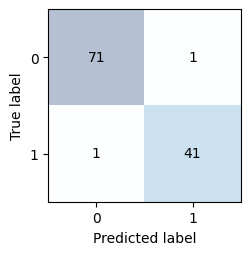

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test)
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)

fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')
ax.xaxis.set_ticks_position('bottom')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


Our best model predicted one false positive (predicted malignant when actually benign) and one false negative (predicted benign when actually malignant).

In [26]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import matthews_corrcoef
pre_val = precision_score(y_true=y_test, y_pred=y_pred)
print(f'Precision: {pre_val:.3f}')
rec_val = recall_score(y_true=y_test, y_pred=y_pred)
print(f'Recall: {rec_val:.3f}')
f1_val = f1_score(y_true=y_test, y_pred=y_pred)
print(f'F1: {f1_val:.3f}')
mcc_val = matthews_corrcoef(y_true=y_test, y_pred=y_pred)
print(f'MCC: {mcc_val:.3f}')

Precision: 0.976
Recall: 0.976
F1: 0.976
MCC: 0.962
